# ACS 2024 Income Model — Experiment 5 — Encoded Learners + Diversified Stack

A working scaffold derived from **`ML_Model_Building_Template.md`**, wired to **`acs2024_income.csv`** — the rich 18-feature ACS 2024 extract produced by `acs2024_income_extraction.ipynb`. Run top-to-bottom.

**Dataset:** `acs2024_income.csv` — 339,727 employed working-age adults, socio-economic predictors from the 2024 ACS PUMS (1-Year).

| Column | Meaning | Kind |
|---|---|---|
| `AGEP` | Age in years | continuous |
| `WKHP` | Usual hours worked per week | continuous |
| `WKWN` | Weeks worked in past 12 months | continuous |
| `COW` | Class of worker (employment sector) | categorical |
| `SCHL` | Education level (ordinal code) | categorical |
| `MAR` | Marital status | categorical |
| `OCCP` | Occupation code | categorical |
| `INDP` | Industry code | categorical |
| `POBP` | Place of birth | categorical |
| `RELSHIPP` | Relationship to householder | categorical |
| `SEX` | Sex | categorical |
| `RAC1P` | Race group | categorical |
| `HISP` | Hispanic origin | categorical |
| `CIT` | Citizenship status | categorical |
| `NATIVITY` | Nativity (native / foreign-born) | categorical |
| `ENG` | English-speaking ability | categorical |
| `DIS` | Disability | categorical |
| `ST` | State (FIPS code) | categorical |
| **`WAGP`** | **Target — wages/salary income (scaled)** | continuous |

| Stage | Name | Key concern |
|---|---|---|
| 1 | Environment Setup | Reproducibility |
| 2 | Data Loading & Preview | Understand structure & quality |
| 3 | Data Cleaning | Missing values -> encoding -> imbalance |
| 4 | Graphical EDA | Distributions & relationships |
| 5 | Feature Set (exp5 mods) | Raw features — no generate/select |
| 6 | Train / Val / Test Split | Stratified, no leakage |
| 7 | Feature Scaling | Fit on train only |
| 8 | Model Architecture | Algorithm choice & hyperparameters |
| 9 | Training | Cross-validation or epoch-based |
| 10 | Learning Curves | Diagnose over/underfitting |
| 11 | Evaluation | Training + test metrics |
| 12 | Save & Inference | Persistence & deployment |

> **Task type:** **regression** — predict `WAGP` from the remaining 18 features. The categorical columns are integer-coded ACS values (`OCCP`, `INDP`, `POBP`, `ST` are high-cardinality), which suits native-categorical gradient-boosted trees.
>
> **Models:** Stages 8-12 benchmark **ten regressors grouped by family** — linear baselines (Ridge, Linear, Lasso), boosted trees (XGBoost, LightGBM, CatBoost), bagging/extra boosting (RandomForest, ExtraTrees, HistGradientBoosting), and a stacking blend of the three boosters. **This is the BASELINE notebook:** it removes the feature modifications (engineered interactions + Select-K-Best) and trains every algorithm on the **raw 18-feature set** — the only shared modification is Log-on-Target. Compare against `acs2024_currBest_model.ipynb`, which adds the feature modifications, to measure what they buy.

---

**Experiment 5 — feature & ensemble modifications (vs the raw-18 baseline):**

1. **Engineered productivity term** `ANNUAL_HOURS = WKHP × WKWN` (Stage 5b) — a direct labour-supply proxy every model can read without forming a product itself.
2. **Leak-safe high-cardinality encoding** (Stage 6b, fit on the *training split only*): out-of-fold (5-fold) smoothed **target encoding** of the high- and medium-cardinality codes (`OCCP/INDP/POBP/ST` + `COW/SCHL/MAR/RELSHIPP/RAC1P/HISP/CIT/ENG`) plus **frequency encoding** of the four high-card codes. **All raw features are kept** — the baseline's lesson was that selection/grouping discard signal.
3. **Encoding-aware routing:** the boosters keep the native-categorical path; the non-native learners (RandomForest / ExtraTrees / HistGB) and the linear models now read the high-card wage signal through the numeric `*_te`/`*_freq` columns instead of meaningless ordinal codes (linear one-hots only the low-card cats, dropping the ~800-column high-card explosion the baseline carried).
4. **Diversified, regularised stack:** the blend widens from 3 boosters to **six base learners** (XGBoost + LightGBM + CatBoost + RandomForest + ExtraTrees + HistGB) with a **Ridge** meta-learner.

> **Goal:** beat the experiment family's best (exp2 Stacking Test R² ≈ 0.5085) by giving every learner the granular high-card wage signal and blending a more diverse base set. The ceiling is feature-bound, so this fuses the two levers shown to help: encode the high-card codes for the weak learners, then blend them.

## Stage 1 — Environment Setup & Library Imports

Import everything upfront, set display options so nothing is truncated, and fix a global seed for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=10000)

## Stage 2 — Data Loading & Textual Preview

Load `acs2024_income.csv` and inspect it textually: shape, head/tail, schema, summary stats, and target distribution. Note any data-quality problems to fix in Stage 3.

In [2]:
# Load dataset
dataset = pd.read_csv("acs2024_income.csv", header=0, index_col=None)

TARGET_COLUMN   = "WAGP"
FEATURE_COLUMNS = [c for c in dataset.columns if c != TARGET_COLUMN]
# Continuous vs. categorical (categoricals are integer-coded ACS values).
# OCCP, INDP, POBP, ST are high-cardinality -> prefer native-categorical models.
CONTINUOUS_COLS  = ["AGEP", "WKHP", "WKWN"]
CATEGORICAL_COLS = ["COW", "SCHL", "MAR", "OCCP", "INDP", "POBP", "RELSHIPP",
                    "SEX", "RAC1P", "HISP", "CIT", "NATIVITY", "ENG", "DIS", "ST"]

print("Shape:", dataset.shape, "\n")
print(dataset.head(), "\n")
print(dataset.tail(), "\n")

Shape: (339727, 19) 

   AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
0    46    40    52    3    20    5  5320  6770     6        25    1      8     2    1         1    1    2  48  0.034315
1    41    40    52    3    20    3  3655  9480    26        20    2      9     1    1         1    0    1  26  0.034519
2    33    45    52    1    19    5  5420  8191    51        22    2      1     1    1         1    0    2  51  0.040610
3    56    40    52    1    12    5  7315   770    13        20    1      1     1    1         1    0    2  13  0.051778
4    61    40    52    1    21    1  2635  7370    51        21    2      1     1    1         1    0    2  51  0.016244 

        AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
339722    33    35    52    1    19    1  6355   770    35        21    1      1     1    1         1    0    2  39  0.12183

<class 'pandas.DataFrame'>
RangeIndex: 339727 entries, 0 to 339726
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   AGEP      339727 non-null  int64  
 1   WKHP      339727 non-null  int64  
 2   WKWN      339727 non-null  int64  
 3   COW       339727 non-null  int64  
 4   SCHL      339727 non-null  int64  
 5   MAR       339727 non-null  int64  
 6   OCCP      339727 non-null  int64  
 7   INDP      339727 non-null  int64  
 8   POBP      339727 non-null  int64  
 9   RELSHIPP  339727 non-null  int64  
 10  SEX       339727 non-null  int64  
 11  RAC1P     339727 non-null  int64  
 12  HISP      339727 non-null  int64  
 13  CIT       339727 non-null  int64  
 14  NATIVITY  339727 non-null  int64  
 15  ENG       339727 non-null  int64  
 16  DIS       339727 non-null  int64  
 17  ST        339727 non-null  int64  
 18  WAGP      339727 non-null  float64
dtypes: float64(1), int64(18)
memory usage: 49.2 MB
None 

 

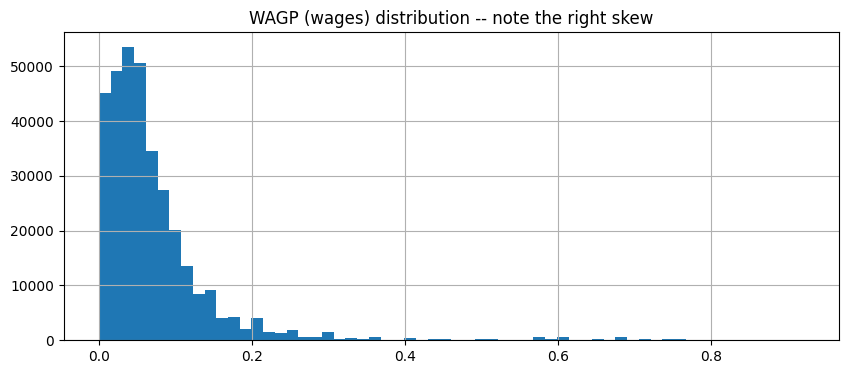

In [3]:
# Structure, dtypes, missing counts, summary stats
print(dataset.info(), "\n")
print(dataset.describe(), "\n")
print("Missing values per column:\n", dataset.isna().sum(), "\n")

# Cardinality of categorical columns (flags high-cardinality features for Stage 8)
print("Unique values per categorical column:")
print(dataset[CATEGORICAL_COLS].nunique().sort_values(ascending=False), "\n")

# Target distribution (regression -> describe + histogram)
print(dataset[TARGET_COLUMN].describe())
dataset[TARGET_COLUMN].hist(bins=60, figsize=(10, 4))
plt.title("WAGP (wages) distribution -- note the right skew"); plt.show()

### Stage 2 — Data-quality notes

- **Shape:** 339,727 rows x 19 columns (18 features + `WAGP` target).
- **No missing values:** the extraction step already filtered and sentinel-filled, so Stage 3a is a guard/no-op here.
- **Categoricals are integer-coded:** no string encoding needed. `OCCP`, `INDP`, `POBP`, and `ST` are high-cardinality (hundreds of levels) -> favour native-categorical learners (CatBoost / XGBoost / LightGBM) over one-hot.
- **Target `WAGP` is already scaled** to roughly `[0, 0.92]` (not raw dollars) and is **right-skewed** -> `log1p` transform in Stage 3d; metrics are converted back to dollars (x1e6) in Stage 11.

## Stage 3 — Data Cleaning & Problem Fixing

Fix problems **before** encoding/transformation, in the template order **missing values -> categorical encoding -> class imbalance**, plus a few dataset-specific checks. For `acs2024_income.csv` most template steps are guards/no-ops (no nulls, already integer-coded, regression target), so each cell below keeps the **recommended** path active and the **alternatives commented** so the full menu is visible.

**The menu**

| Sub-stage | Recommended (active) | Alternatives (commented) |
|---|---|---|
| 3a Missing values | guard (no nulls present) | KNN / median impute; sentinel level |
| 3b Categorical encoding | keep native, enforce `int` codes | one-hot (low-card only); ordinal (`SCHL`/`ENG`); frequency/target encode (high-card); coarsen to ACS rollups |
| 3c Class imbalance | N/A (continuous target) | bracket `WAGP` + SMOTE/undersample (classification variant) |
| 3d Dataset-specific | duplicate check; `log1p` target | winsorize top-coded tail |

In [4]:
# 3a -- Missing values. acs2024_income.csv has NONE, so this is a guard/no-op.
# (The extractor already sentinel-filled non-applicable OCCP/INDP with -1, i.e.
#  "no occupation/industry" is its own category rather than a NaN.)
from sklearn.impute import KNNImputer

cols_with_nulls = [c for c in dataset.columns if dataset[c].isna().any()]
if cols_with_nulls:
    cont_nulls = [c for c in cols_with_nulls if c in CONTINUOUS_COLS]
    cat_nulls  = [c for c in cols_with_nulls if c in CATEGORICAL_COLS]
    if cont_nulls:                                   # continuous -> KNN (or median)
        dataset[cont_nulls] = KNNImputer(n_neighbors=5).fit_transform(dataset[cont_nulls])
    for c in cat_nulls:                              # categorical -> dedicated sentinel
        dataset[c] = dataset[c].fillna(-1)

print("Columns with nulls:", cols_with_nulls)
print("Remaining missing values:", int(dataset.isna().sum().sum()))

Columns with nulls: []
Remaining missing values: 0


In [5]:
# 3b -- Categorical handling. Columns are ALREADY integer-coded ACS values, so no
# string encoding is needed; the real decision is how DOWNSTREAM models treat them.
HIGH_CARD = ["OCCP", "INDP", "POBP", "ST"]                 # 525 / 257 / 222 / 51 levels
LOW_CARD  = [c for c in CATEGORICAL_COLS if c not in HIGH_CARD]

# === RECOMMENDED: keep native categorical, just enforce integer codes ==========
# CatBoost consumes these directly via cat_features; XGBoost/LightGBM via category dtype.
for c in CATEGORICAL_COLS:
    dataset[c] = dataset[c].astype(int)
print("Categoricals enforced as int. High-cardinality levels:",
      {c: int(dataset[c].nunique()) for c in HIGH_CARD})

# === ALTERNATIVE 1 -- One-hot the LOW-cardinality columns only =================
# Good for linear / distance models. NEVER one-hot OCCP/INDP/POBP (-> 1000+ cols).
# dataset = pd.get_dummies(dataset, columns=LOW_CARD, drop_first=True)

# === ALTERNATIVE 2 -- Ordinal encode the genuinely ORDERED columns =============
# Only SCHL (education) and ENG (English ability) have a meaningful order; they are
# already monotonic codes, so use this only if starting from raw string categories.
# from sklearn.preprocessing import OrdinalEncoder
# dataset[["SCHL", "ENG"]] = OrdinalEncoder().fit_transform(dataset[["SCHL", "ENG"]])

# === ALTERNATIVE 3 -- Frequency / target encoding for HIGH-cardinality =========
# For models WITHOUT native categorical support (sklearn RF, linear). Frequency
# encoding is leak-free; target encoding MUST be fit inside CV folds (Stage 6+).
# for c in HIGH_CARD:
#     dataset[c + "_freq"] = dataset[c].map(dataset[c].value_counts(normalize=True))

# === ALTERNATIVE 4 -- Coarsen high-cardinality codes to ACS rollups ============
# dataset["OCCP_grp"] = (dataset["OCCP"] // 100).astype(int)    # ~major occ groups
# dataset["INDP_grp"] = (dataset["INDP"] // 1000).astype(int)   # ~sectors

Categoricals enforced as int. High-cardinality levels: {'OCCP': 525, 'INDP': 257, 'POBP': 222, 'ST': 51}


In [6]:
# 3c -- Class imbalance: NOT APPLICABLE (WAGP is a continuous regression target).
# Only relevant for a CLASSIFICATION variant where WAGP is binned into brackets:
# brackets = pd.qcut(dataset[TARGET_COLUMN], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
# then rebalance the resulting classes (SVMSMOTE / RandomUnderSampler).
print("Regression target -- no resampling applied.")

Regression target -- no resampling applied.


In [7]:
# 3d -- Dataset-specific checks beyond the template.

# Duplicate rows: PUMS can legitimately repeat identical feature rows -> inspect, keep.
print("Exact duplicate rows:", int(dataset.duplicated().sum()))

# Outliers / top-coding: Census top-codes very high wages, compressing the right tail.
# WAGP here is already scaled to ~[0, 0.92]. OPTIONAL winsorize at the 99.5th pct:
# cap = dataset[TARGET_COLUMN].quantile(0.995)
# dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].clip(upper=cap)

# Target transform (right-skew): build a log1p target as a SEPARATE series (do NOT
# add it as a feature column). Invert with expm1 before reporting metrics in Stage 11.
y_log = np.log1p(dataset[TARGET_COLUMN])
print("\nlog1p(WAGP) summary:")
print(y_log.describe())

Exact duplicate rows: 1352

log1p(WAGP) summary:
count    339727.000000
mean          0.068582
std           0.068556
min           0.000004
25%           0.030003
50%           0.051447
75%           0.087436
max           0.652758
Name: WAGP, dtype: float64


## Stage 4 — Graphical Data Exploration (EDA)

Visualise distributions and relationships before engineering features. The skewed continuous histograms justify the target transform; the grouped-median bars and the focused scatter confirm the headline socio-economic signal (education, hours, sex) is present.

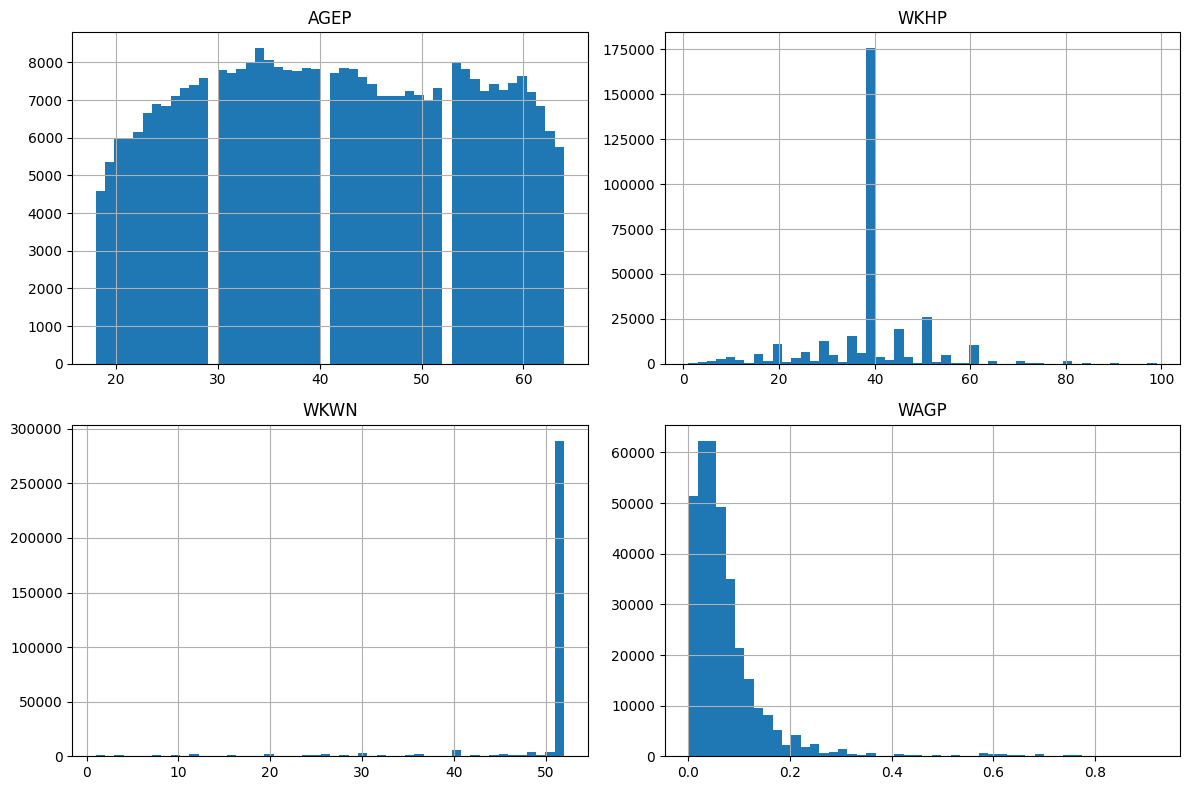

In [8]:
# Distribution of the continuous features + target. (Categorical columns are integer
# CODES, so a numeric histogram of them is not meaningful -- a few key ones are shown
# as grouped medians below instead.)
dataset[CONTINUOUS_COLS + [TARGET_COLUMN]].hist(bins=50, figsize=(12, 8))
plt.tight_layout(); plt.show()

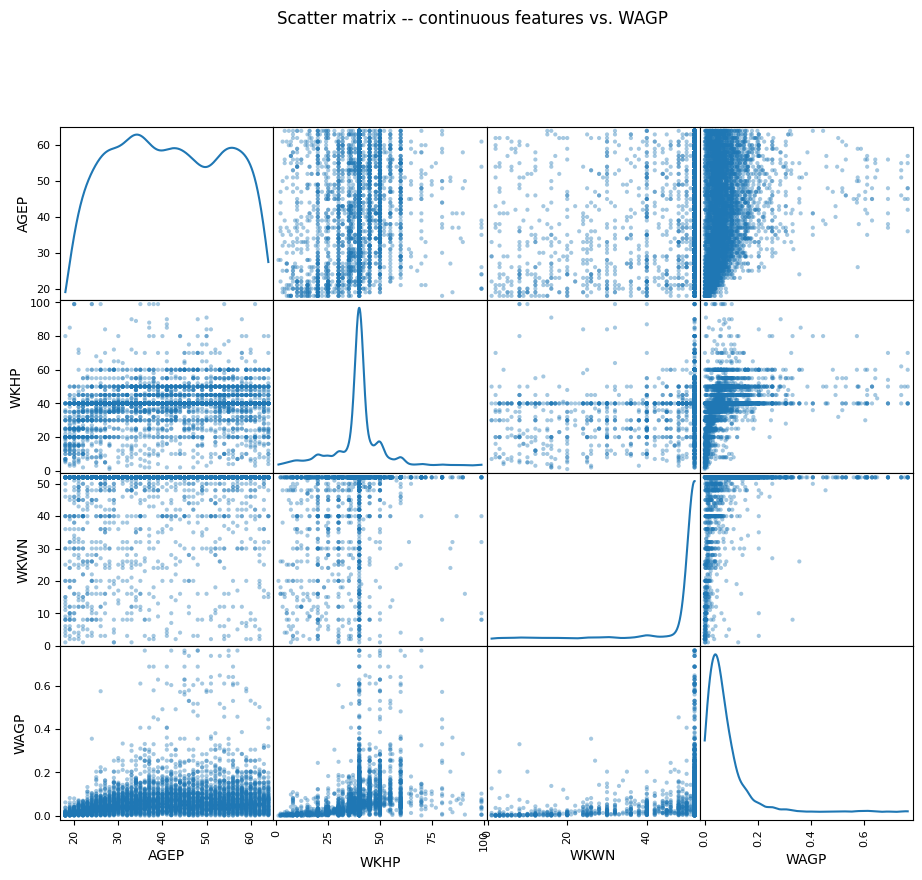

In [9]:
# Pairwise scatter matrix on the continuous features + target (sampled for speed).
from pandas.plotting import scatter_matrix

attrs = CONTINUOUS_COLS + [TARGET_COLUMN]
scatter_matrix(dataset[attrs].sample(5000, random_state=RANDOM_STATE),
               alpha=0.4, figsize=(11, 9), diagonal="kde")
plt.suptitle("Scatter matrix -- continuous features vs. WAGP", y=1.01); plt.show()

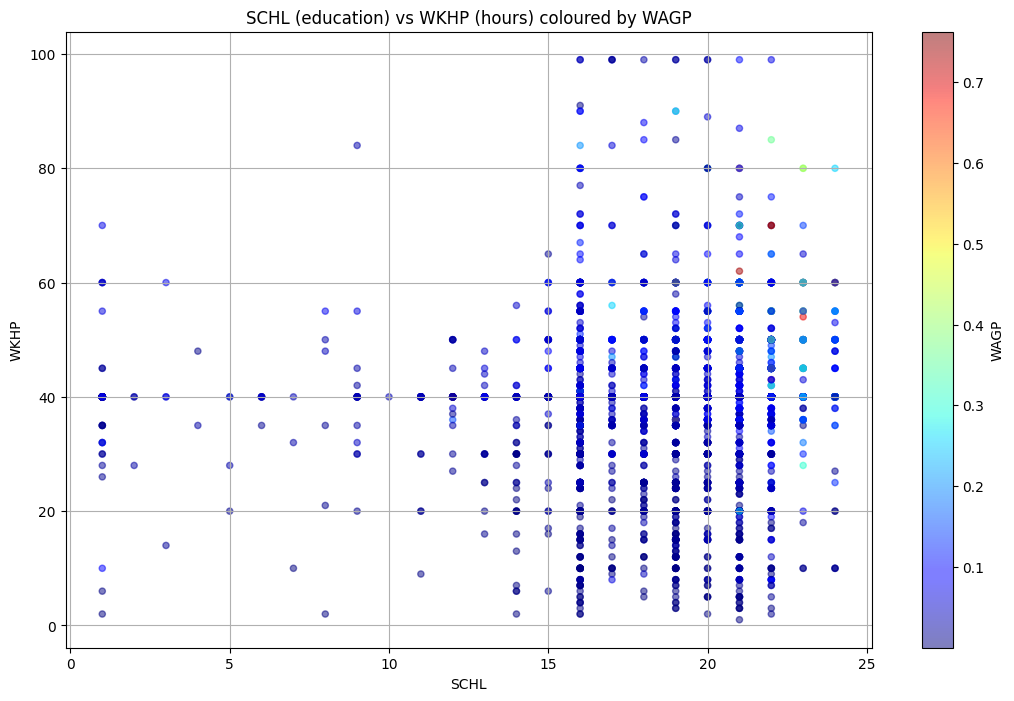

In [10]:
# Focused scatter: education vs. usual hours worked, coloured by wage.
dataset.sample(5000, random_state=RANDOM_STATE).plot(
    kind="scatter", x="SCHL", y="WKHP", c=TARGET_COLUMN, cmap="jet",
    colorbar=True, grid=True, figsize=(13, 8), alpha=0.5)
plt.title("SCHL (education) vs WKHP (hours) coloured by WAGP"); plt.show()

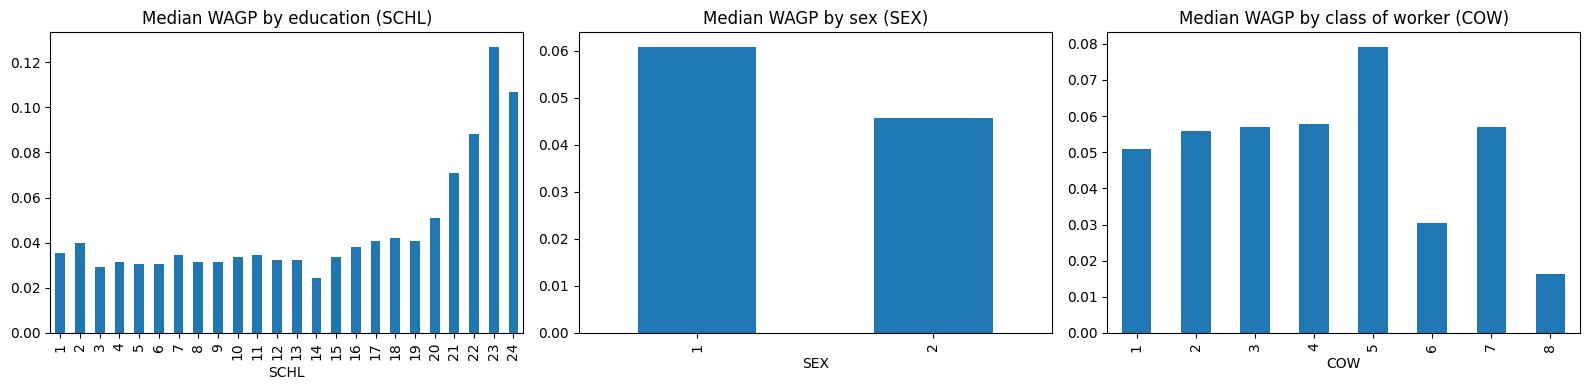

In [11]:
# Signal check: median wage by a few key categoricals (codes ordered on the x-axis).
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
dataset.groupby("SCHL")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[0])
ax[0].set_title("Median WAGP by education (SCHL)")
dataset.groupby("SEX")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[1])
ax[1].set_title("Median WAGP by sex (SEX)")
dataset.groupby("COW")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[2])
ax[2].set_title("Median WAGP by class of worker (COW)")
plt.tight_layout(); plt.show()

## Stage 5 — Feature Set (exp5: engineered + encoded features)

**exp5 modifications.** Building on the baseline's finding that *keeping* all raw signal beats selection/grouping, exp5 keeps every raw feature and **adds** one engineered term (`ANNUAL_HOURS`) here, then layers leak-safe target/frequency **encodings** of the high-cardinality codes in Stage 6b (after the split, so they cannot leak). No feature is dropped.

We still rank features by **mutual information** against `log1p(WAGP)` for insight, and show a Pearson heatmap of the raw numeric features — but nothing is generated or dropped.

In [12]:
# 5a -- Feature identification. Baseline keeps the RAW feature columns only (no
# engineered interactions). y_sel is the log1p target from Stage 3d; trgt_y keeps raw
# WAGP for dollar-scale reporting later.
feats_X = dataset[FEATURE_COLUMNS].copy()
trgt_y  = pd.DataFrame(dataset[[TARGET_COLUMN]])
y_sel   = y_log
print("feats_X (raw 18 features):", feats_X.shape, "| trgt_y:", trgt_y.shape)

feats_X (raw 18 features): (339727, 18) | trgt_y: (339727, 1)


In [13]:
# 5b -- Feature generation. exp5 adds ONE engineered productivity term to the raw set:
# ANNUAL_HOURS = usual weekly hours x weeks worked -> a direct annual labour-supply proxy
# that EVERY learner (including the linear / forest models) can use without having to
# discover the WKHP x WKWN product on its own.
GENERATED_COLS = ["ANNUAL_HOURS"]
feats_X["ANNUAL_HOURS"] = (feats_X["WKHP"] * feats_X["WKWN"]).astype(float)
print("exp5 engineered feature:", GENERATED_COLS, "-> feats_X", feats_X.shape)

exp5 engineered feature: ['ANNUAL_HOURS'] -> feats_X (339727, 19)


In [14]:
# 5c -- Feature selection: SKIPPED for the baseline (no Select-K-Best). We still rank
# all features by mutual information for INSIGHT, but keep EVERY raw feature so the
# benchmark reflects the unmodified set.
from sklearn.feature_selection import mutual_info_regression

ALL_FEATURES  = list(feats_X.columns)
discrete_mask = [c in CATEGORICAL_COLS for c in ALL_FEATURES]

samp = feats_X.sample(min(20000, len(feats_X)), random_state=RANDOM_STATE)
mi_scores = pd.Series(
    mutual_info_regression(samp, y_sel.loc[samp.index],
                           discrete_features=discrete_mask, random_state=RANDOM_STATE),
    index=ALL_FEATURES).sort_values(ascending=False)
selected = ALL_FEATURES                          # keep ALL -> baseline
print('Mutual information with log(WAGP):')
print(mi_scores.round(4))
print('Baseline keeps all', len(selected), 'features:', selected)

Mutual information with log(WAGP):
OCCP            0.3398
ANNUAL_HOURS    0.3035
WKHP            0.2272
INDP            0.1841
WKWN            0.1388
SCHL            0.1326
AGEP            0.1167
RELSHIPP        0.1107
MAR             0.0598
ST              0.0533
POBP            0.0300
COW             0.0215
RAC1P           0.0211
HISP            0.0150
CIT             0.0129
SEX             0.0115
ENG             0.0112
NATIVITY        0.0046
DIS             0.0030
dtype: float64
Baseline keeps all 19 features: ['AGEP', 'WKHP', 'WKWN', 'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST', 'ANNUAL_HOURS']


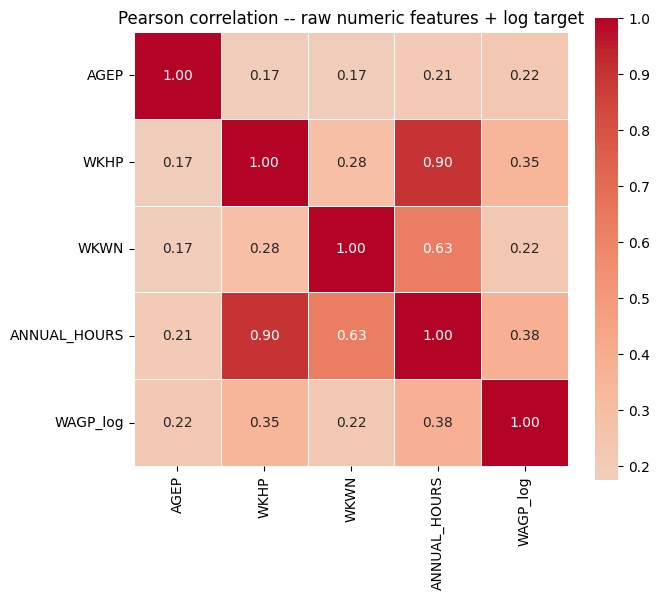

In [15]:
# 5c (heatmap) -- multicollinearity check on the RAW numeric features + target only.
numeric_cols = CONTINUOUS_COLS + GENERATED_COLS  # exp5: include ANNUAL_HOURS
corr = pd.concat([feats_X[numeric_cols], y_log.rename("WAGP_log")], axis=1).corr("pearson")

plt.figure(figsize=(7, 6))
sbn.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Pearson correlation -- raw numeric features + log target"); plt.show()

In [16]:
# Finalise the baseline feature set: ALL raw features, no generation, no selection.
useful_feats_X = feats_X[selected].copy()
print("Baseline feature set:", list(useful_feats_X.columns))
print("useful_feats_X:", useful_feats_X.shape)

Baseline feature set: ['AGEP', 'WKHP', 'WKWN', 'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST', 'ANNUAL_HOURS']
useful_feats_X: (339727, 19)


## Stage 6 — Train / Validation / Test Split

Regression target -> a plain shuffled `train_test_split` (an optional `qcut`-bin stratification is shown to balance income *ranges*). A validation slice is carved from train for early stopping. Targets are `log1p(WAGP)`; the `*_raw` series recover the (scaled) WAGP axis via `expm1`, then Stage 11 multiplies by 1e6 for dollars.

In [17]:
from sklearn.model_selection import train_test_split

X = useful_feats_X
y = y_sel                                   # = y_log, index-aligned with X

# Categorical subset that survived selection -> native categorical handling in Stage 8.
CAT_FEATURES = [c for c in X.columns if c in CATEGORICAL_COLS]
print("Categorical features carried into the models:", CAT_FEATURES)

# Primary 80/20 train-test split (shuffled).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Optional: balance income RANGES across splits instead (uncomment to stratify):
# strat_bins = pd.qcut(y, q=10, labels=False)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=strat_bins)

# Carve a validation slice out of train (early stopping).
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Raw-axis targets aligned to each split (expm1 inverts the log1p), for Stage 11.
y_train_raw = np.expm1(y_train)
y_val_raw   = np.expm1(y_val)
y_test_raw  = np.expm1(y_test)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

Categorical features carried into the models: ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']
X_train: (217424, 19) | X_val: (54357, 19) | X_test: (67946, 19)


## Stage 6b — Leak-safe high-cardinality encoding

The high-cardinality ACS codes (`OCCP`, `INDP`, `POBP`, `ST`) carry most of the wage signal,
but only the native-categorical boosters can exploit them — the linear and sklearn-forest
models read the raw integer codes as meaningless *ordinals*. exp5 fixes that by adding numeric
**target** and **frequency** encodings, computed **strictly on the training split** so nothing
leaks into validation/test:

- **Target encoding** uses an out-of-fold (5-fold) scheme on `X_train` with global-mean
  smoothing, so a row's own target never informs its own encoding. Validation/test rows are
  mapped with the *full-train* smoothed means.
- **Frequency encoding** (leak-free by construction) gives the rarity of each high-card level.

All raw columns are preserved; the encodings are *additional* numeric features.

In [18]:
# Stage 6b -- leak-safe target & frequency encoding (fit on TRAIN only).
from sklearn.model_selection import KFold

ENC_HIGH = ["OCCP", "INDP", "POBP", "ST"]                       # high-cardinality codes
ENC_MED  = ["COW", "SCHL", "MAR", "RELSHIPP", "RAC1P", "HISP", "CIT", "ENG"]
ENC_COLS = ENC_HIGH + ENC_MED
SMOOTH      = 50.0                                              # global-mean shrinkage strength
global_mean = float(y_train.mean())                            # prior for unseen / rare levels

def _smoothed_means(cat, targ):
    """Smoothed per-level target mean: (sum + prior*SMOOTH) / (n + SMOOTH)."""
    agg = targ.groupby(cat).agg(["mean", "count"])
    return (agg["mean"] * agg["count"] + global_mean * SMOOTH) / (agg["count"] + SMOOTH)

# Work on copies so the raw frames stay intact, then swap them in at the end.
X_tr, X_va, X_te = X_train.copy(), X_val.copy(), X_test.copy()
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for col in ENC_COLS:
    # --- out-of-fold target encoding for TRAIN (no row sees its own target) ---
    oof = np.empty(len(X_train), dtype=float)
    for tr_idx, va_idx in kf.split(X_train):
        sm = _smoothed_means(X_train[col].iloc[tr_idx], y_train.iloc[tr_idx])
        oof[va_idx] = X_train[col].iloc[va_idx].map(sm).fillna(global_mean).to_numpy()
    X_tr[col + "_te"] = oof
    # --- full-train means map onto val / test ---
    full_sm = _smoothed_means(X_train[col], y_train)
    X_va[col + "_te"] = X_val[col].map(full_sm).fillna(global_mean).to_numpy()
    X_te[col + "_te"] = X_test[col].map(full_sm).fillna(global_mean).to_numpy()

# --- frequency encoding for the high-card codes (leak-free: train frequencies) ---
for col in ENC_HIGH:
    freq = X_train[col].value_counts(normalize=True)
    X_tr[col + "_freq"] = X_train[col].map(freq).fillna(0.0).to_numpy()
    X_va[col + "_freq"] = X_val[col].map(freq).fillna(0.0).to_numpy()
    X_te[col + "_freq"] = X_test[col].map(freq).fillna(0.0).to_numpy()

ENC_FEATURES = [c + "_te" for c in ENC_COLS] + [c + "_freq" for c in ENC_HIGH]
X_train, X_val, X_test = X_tr, X_va, X_te        # downstream stages use the augmented frames

print("Added", len(ENC_FEATURES), "encoded features:", ENC_FEATURES)
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print("Sanity (train OCCP_te corr with target): "
      f"{np.corrcoef(X_train['OCCP_te'], y_train)[0, 1]:.3f}")

Added 16 encoded features: ['OCCP_te', 'INDP_te', 'POBP_te', 'ST_te', 'COW_te', 'SCHL_te', 'MAR_te', 'RELSHIPP_te', 'RAC1P_te', 'HISP_te', 'CIT_te', 'ENG_te', 'OCCP_freq', 'INDP_freq', 'POBP_freq', 'ST_freq']
X_train: (217424, 35) | X_val: (54357, 35) | X_test: (67946, 35)
Sanity (train OCCP_te corr with target): 0.561


## Stage 7 — Feature Scaling / Normalisation

**Primary (tree) path: no scaling.** Gradient-boosted trees are scale-invariant, the target is already `log1p`-transformed, and scaling would corrupt the integer category codes. The commented **DL / linear branch** shows the leakage-safe pattern: fit on **train only**, transform **numeric features only**.

In [19]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler

# === PRIMARY (tree) path: NO scaling -- pass through ===========================
X_train_sc, X_val_sc, X_test_sc = X_train, X_val, X_test
y_train_sc, y_val_sc, y_test_sc = y_train, y_val, y_test
print("Tree path: features passed through unscaled.")

# === ALTERNATIVE (DL / linear branch): scale NUMERIC features only =============
# NUMERIC_COLS = [c for c in X_train.columns if c not in CAT_FEATURES]
# scaler_X = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE)
# scaler_X.fit(X_train[NUMERIC_COLS])
# def _scale(df):
#     out = df.copy(); out[NUMERIC_COLS] = scaler_X.transform(df[NUMERIC_COLS]); return out
# X_train_sc, X_val_sc, X_test_sc = _scale(X_train), _scale(X_val), _scale(X_test)

Tree path: features passed through unscaled.


## Stage 8 — Model Selection, Architecture & Compilation

Ten regressors are configured and benchmarked, grouped by family, all on the same selected features and the same `log1p(WAGP)` target:

**1. Linear baselines — Ridge / plain Linear / Lasso.** A floor for the comparison. They can't consume the integer ACS codes directly (those codes are *nominal* — a larger `OCCP` isn't "more"), so each is wrapped in a `Pipeline` whose `ColumnTransformer` **standardises the numeric features and one-hot encodes the categoricals**, fit on the training fold only (leakage-safe).

**2. Boosted trees — XGBoost / LightGBM / CatBoost.** Matched hyperparameters (`~2000` trees, `lr=0.05`, `max_depth=8`, L2, early stopping) so differences reflect the *algorithm*. All three ingest the categoricals **natively**, including high-cardinality `OCCP`/`INDP`/`ST`:
- **CatBoost** — `cat_features` (ordered boosting). **XGBoost** — `enable_categorical=True`. **LightGBM** — `categorical_feature=` (both need pandas `category` dtype).

**3. Bagging & extra boosting — RandomForest / ExtraTrees / HistGradientBoosting.** Contrasting tree paradigms (bagging vs. boosting) **without** native high-cardinality support — they read the integer codes as *ordinal*, so they're the "no native categoricals" comparison point. HistGB's native categorical mode caps at 255 categories, which `OCCP`(525)/`INDP`(257) exceed, so it too treats the codes as ordinal.

**4. Stacking ensemble — blend of XGBoost + LightGBM + CatBoost.** A `StackedGBM` holdout-blender: the three fitted boosters predict on the held-out validation split, and a linear meta-learner learns how to weight them. This is the one model most likely to edge past the individual boosters. (A holdout blend is used instead of full CV stacking because re-fitting three heavy boosters across CV folds on 217k rows is far more expensive for a marginal gain.)

In [20]:
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

cat_model = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=10,
    loss_function="RMSE", eval_metric="RMSE", random_state=RANDOM_STATE,
    early_stopping_rounds=100, verbose=400)

xgb_model = XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=10, tree_method="hist",
    enable_categorical=True, early_stopping_rounds=100,
    random_state=RANDOM_STATE, verbosity=0)

lgb_model = LGBMRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=10,
    random_state=RANDOM_STATE, verbose=-1)

print("Configured CatBoost, XGBoost, LightGBM.")
print("Categorical features:", CAT_FEATURES)

# --- Linear baselines: Ridge / Linear / Lasso --------------------------------
# Unlike the trees, linear models can't read the integer ACS codes directly: those
# codes are NOMINAL (a higher OCCP number isn't "more"), so they must be one-hot'd,
# and the numeric features must be standardised. A ColumnTransformer does both and is
# fit INSIDE each pipeline -> on the training fold only, so the split stays leak-free.
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# exp5: linear models read the high-card codes through their numeric target/freq encodings
# (ENC_FEATURES) instead of an ~800-column one-hot of OCCP/INDP/POBP/ST. Only the LOW-card
# cats are one-hot'd, which is both faster and gives the linear family the high-card signal.
LOW_CARD_CATS      = [c for c in CAT_FEATURES if c not in ["OCCP", "INDP", "POBP", "ST"]]
NUMERIC_FOR_LINEAR = CONTINUOUS_COLS + GENERATED_COLS + ENC_FEATURES
linear_pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FOR_LINEAR),
    ("cat", OneHotEncoder(handle_unknown="ignore"), LOW_CARD_CATS),
])

def make_linear(estimator):
    """Wrap a linear estimator with the shared scale + one-hot preprocessor."""
    return Pipeline([("prep", linear_pre), ("model", estimator)])

ridge_model  = make_linear(Ridge(alpha=1.0))
linear_model = make_linear(LinearRegression())
lasso_model  = make_linear(Lasso(alpha=1e-4, max_iter=3000, random_state=RANDOM_STATE))

print("\nConfigured Ridge, LinearRegression, Lasso (StandardScaler + OneHotEncoder pipeline).")
print("Numeric  ->", NUMERIC_FOR_LINEAR)
print("One-hot  ->", LOW_CARD_CATS)

# --- Bagging & extra-boosting baselines: RandomForest / ExtraTrees / HistGB ---
# None of these have native high-cardinality categorical support, so they read the
# integer ACS codes as ORDINAL numbers (a known limitation vs CatBoost/LightGBM). We
# still feed the plain integer frames -- one-hot would explode OCCP(525)/INDP(257) and
# is unnecessary for trees. This makes them a fair "no native categoricals" contrast.
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              HistGradientBoostingRegressor)

rf_model = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)

et_model = ExtraTreesRegressor(
    n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)

# HistGB's native categorical mode caps at 255 categories/feature, but OCCP(525)/INDP(257)
# exceed that -> we let it treat the codes as ordinal and use its built-in early stopping
# (internal validation split carved from train).
hgb_model = HistGradientBoostingRegressor(
    max_iter=2000, learning_rate=0.05, max_depth=8, l2_regularization=10,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=50,
    random_state=RANDOM_STATE)

print("\nConfigured RandomForest, ExtraTrees, HistGradientBoosting (plain integer codes).")

# --- Stacking ensemble of the three boosters (XGB + LightGBM + CatBoost) ------
# Holdout BLEND (cheaper than full CV stacking on 217k x 3 heavy models): the three
# already-fitted boosters predict on the held-out VALIDATION split, and a linear
# meta-learner learns how to weight them. Leakage-safe -- bases train on X_train, the
# meta trains on X_val, and everything is finally scored on the untouched X_test.
class StackedGBM:
    """Blend XGBoost + LightGBM + CatBoost predictions with a linear meta-learner.

    predict() accepts the PLAIN integer frame and rebuilds the category-dtype copy that
    XGBoost/LightGBM need, casting with the TRAINING categories so the integer->code
    mapping stays consistent (unseen levels become NaN = missing, handled natively)."""
    def __init__(self, base_models, cat_dtypes, meta=None):
        self.base_models = base_models      # list of (name, fitted_model, needs_category)
        self.cat_dtypes  = cat_dtypes       # {col: training CategoricalDtype}
        self.meta = meta if meta is not None else LinearRegression()

    def _stack(self, X):
        Xc = X.copy()
        for c, dt in self.cat_dtypes.items():
            Xc[c] = Xc[c].astype(dt)        # cast with the train category set
        preds = [m.predict(Xc if need_cat else X)
                 for _, m, need_cat in self.base_models]
        return np.column_stack(preds)

    def fit(self, X_blend, y_blend):
        self.meta.fit(self._stack(X_blend), y_blend)
        return self

    def predict(self, X):
        return self.meta.predict(self._stack(X))

print("Defined StackedGBM blender (meta-learner: LinearRegression).")

Configured CatBoost, XGBoost, LightGBM.
Categorical features: ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']

Configured Ridge, LinearRegression, Lasso (StandardScaler + OneHotEncoder pipeline).
Numeric  -> ['AGEP', 'WKHP', 'WKWN', 'ANNUAL_HOURS', 'OCCP_te', 'INDP_te', 'POBP_te', 'ST_te', 'COW_te', 'SCHL_te', 'MAR_te', 'RELSHIPP_te', 'RAC1P_te', 'HISP_te', 'CIT_te', 'ENG_te', 'OCCP_freq', 'INDP_freq', 'POBP_freq', 'ST_freq']
One-hot  -> ['COW', 'SCHL', 'MAR', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS']

Configured RandomForest, ExtraTrees, HistGradientBoosting (plain integer codes).
Defined StackedGBM blender (meta-learner: LinearRegression).


## Stage 9 — Training

Models are fit in family order. The **linear baselines** and the **RandomForest / ExtraTrees / HistGradientBoosting** trees fit on the plain integer training split (the linear pipelines scale + one-hot internally; HistGB carves its own early-stopping slice). The three **boosters** then train on the `log1p` target with early stopping against our validation split — CatBoost via `Pool`, XGBoost/LightGBM on **`category`-dtype copies** (built once below, with val/test cast to the *training* categories so the codes stay consistent). Finally the **`StackedGBM`** blender fits its linear meta-learner on the boosters' validation-set predictions. The `MODELS` dict is assembled in benchmark order and records the frame each model predicts on.

In [21]:
import time, lightgbm as lgb

# Category-dtype copies for XGBoost / LightGBM. Build the TRAIN frame first to fix the
# category set, then cast val/test to the SAME categories so the integer->code mapping is
# consistent across splits (levels unseen in train become NaN = missing, handled natively).
def as_category(df, ref=None):
    out = df.copy()
    for c in CAT_FEATURES:
        out[c] = out[c].astype("category") if ref is None else out[c].astype(ref[c].dtype)
    return out
X_train_cat = as_category(X_train)
X_val_cat   = as_category(X_val,  ref=X_train_cat)
X_test_cat  = as_category(X_test, ref=X_train_cat)

# --- Linear baselines (own scale + one-hot pipeline; no validation / early stopping) ---
for nm, lm in [("Ridge", ridge_model), ("Linear", linear_model), ("Lasso", lasso_model)]:
    t0 = time.time(); lm.fit(X_train, y_train)
    print(f"{nm:20s} trained {time.time()-t0:6.1f}s")

# --- Bagging / HistGB baselines (plain integer frames; trees split on the codes) ---
for nm, tm in [("RandomForest", rf_model), ("ExtraTrees", et_model),
               ("HistGradientBoosting", hgb_model)]:
    t0 = time.time(); tm.fit(X_train, y_train)
    print(f"{nm:20s} trained {time.time()-t0:6.1f}s")

# --- CatBoost (native Pool) ---
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
val_pool   = Pool(X_val,   y_val,   cat_features=CAT_FEATURES)
t0 = time.time(); cat_model.fit(train_pool, eval_set=val_pool)
print(f"{'CatBoost':20s} trained {time.time()-t0:6.1f}s | best_iter {cat_model.get_best_iteration()}")

# --- XGBoost ---
t0 = time.time(); xgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], verbose=False)
print(f"{'XGBoost':20s} trained {time.time()-t0:6.1f}s | best_iter {xgb_model.best_iteration}")

# --- LightGBM ---
t0 = time.time()
lgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], eval_metric="rmse",
              categorical_feature=CAT_FEATURES,
              callbacks=[lgb.early_stopping(100, verbose=False)])
print(f"{'LightGBM':20s} trained {time.time()-t0:6.1f}s | best_iter {lgb_model.best_iteration_}")

# --- Stacking ensemble: blend the 3 fitted boosters on the held-out validation split ---
cat_dtypes  = {c: X_train_cat[c].dtype for c in CAT_FEATURES}
stack_model = StackedGBM(          # exp5: 6 diverse bases, regularised Ridge meta-learner
    base_models=[("XGBoost", xgb_model, True),
                 ("LightGBM", lgb_model, True),
                 ("CatBoost", cat_model, False),
                 ("RandomForest", rf_model, False),
                 ("ExtraTrees", et_model, False),
                 ("HistGradientBoosting", hgb_model, False)],
    cat_dtypes=cat_dtypes, meta=Ridge(alpha=1.0))
t0 = time.time(); stack_model.fit(X_val, y_val)   # meta learns weights on out-of-base-sample preds
w = stack_model.meta.coef_
_bn = [n for n, _, _ in stack_model.base_models]
print(f"{'Stacking(GBMs)':20s} trained {time.time()-t0:6.1f}s | meta(Ridge) weights " +
      " ".join(f"{n[:4]}={c:+.2f}" for n, c in zip(_bn, w)))

# Benchmark order: linear -> original boosters -> bagging/HistGB -> stacking (capstone).
# Each entry maps a model to the frames it predicts on in Stage 11.
MODELS = {
    "Ridge":    (ridge_model,  X_train,     X_test),
    "Linear":   (linear_model, X_train,     X_test),
    "Lasso":    (lasso_model,  X_train,     X_test),
    "XGBoost":  (xgb_model,    X_train_cat, X_test_cat),
    "LightGBM": (lgb_model,    X_train_cat, X_test_cat),
    "CatBoost": (cat_model,    X_train,     X_test),
    "RandomForest":         (rf_model,    X_train, X_test),
    "ExtraTrees":           (et_model,    X_train, X_test),
    "HistGradientBoosting": (hgb_model,   X_train, X_test),
    "Stacking(GBMs)":       (stack_model, X_train, X_test),
}

Ridge                trained    1.8s


Linear               trained    2.3s


Lasso                trained    1.5s


RandomForest         trained   20.9s


ExtraTrees           trained   11.3s


...

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.04587569329
bestIteration = 1789

Shrink model to first 1790 iterations.


CatBoost             trained  208.2s | best_iter 1789


XGBoost              trained    3.4s | best_iter 216


LightGBM             trained    1.6s | best_iter 261


Stacking(GBMs)       trained    0.9s | meta(Ridge) weights XGBo=+0.14 Ligh=+0.26 CatB=+0.31 Rand=+0.04 Extr=+0.10 Hist=+0.14


## Stage 10 — Learning Curve Visualisation

Left: CatBoost **train vs. validation** RMSE (the template's over/underfit diagnosis — a widening gap signals overfitting). Right: **validation RMSE for the three boosted-tree algorithms** overlaid, so their convergence and early-stopping points are directly comparable. (The linear baselines fit in closed form / coordinate descent with no boosting iterations, so they have no learning curve.) All curves are on the `log1p` target axis.

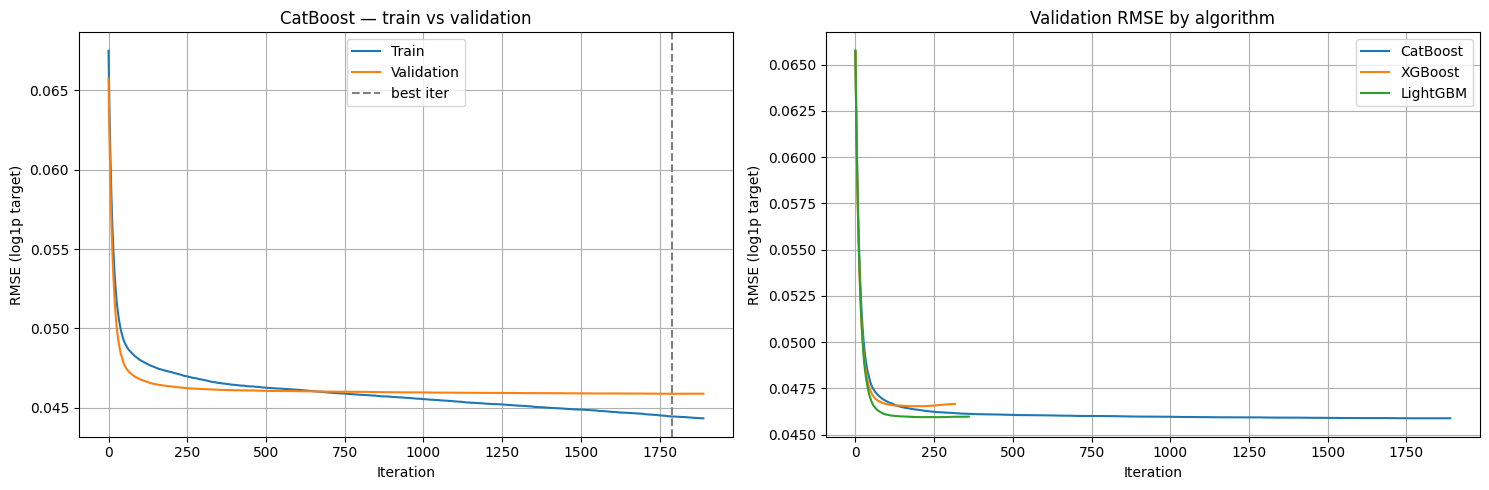

In [22]:
ev_cat = cat_model.get_evals_result()
ev_xgb = xgb_model.evals_result()
ev_lgb = lgb_model.evals_result_

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: CatBoost train vs validation
ax[0].plot(ev_cat["learn"]["RMSE"], label="Train")
ax[0].plot(ev_cat["validation"]["RMSE"], label="Validation")
ax[0].axvline(cat_model.get_best_iteration(), ls="--", c="grey", label="best iter")
ax[0].set_title("CatBoost — train vs validation")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("RMSE (log1p target)")
ax[0].legend(); ax[0].grid()

# Right: validation RMSE overlay across the three algorithms
ax[1].plot(ev_cat["validation"]["RMSE"],   label="CatBoost")
ax[1].plot(ev_xgb["validation_0"]["rmse"], label="XGBoost")
ax[1].plot(ev_lgb["valid_0"]["rmse"],      label="LightGBM")
ax[1].set_title("Validation RMSE by algorithm")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("RMSE (log1p target)")
ax[1].legend(); ax[1].grid()

plt.tight_layout(); plt.show()

## Stage 11 — Evaluation on Training & Test Sets

Score every model on **both** train and test so the train-vs-test gap is visible. Predictions are made on the `log1p` axis, inverted with `expm1`, then multiplied by `WAGP_TO_DOLLARS = 1e6` to report **MAE / RMSE in dollars** (the extractor stored `WAGP` as adjusted dollars / 1e6). `R²` / Explained Variance are scale-free. The printed rows match the Experiment-Log format; `results_df` collects them.

In [23]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             explained_variance_score, r2_score)

WAGP_TO_DOLLARS = 1_000_000
MODS = "exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack)"

rows = []
print("| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |")
print("|---|---|---|---|---|---|---|---|")
for name, (m, X_tr, X_te) in MODELS.items():           # MODELS is in benchmark order
    p_tr = np.expm1(m.predict(X_tr)) * WAGP_TO_DOLLARS
    p_te = np.expm1(m.predict(X_te)) * WAGP_TO_DOLLARS
    yt_tr = y_train_raw.values * WAGP_TO_DOLLARS
    yt_te = y_test_raw.values  * WAGP_TO_DOLLARS
    row = {
        "Algorithm": name, "Modifications": MODS,
        "Train MAE":  mean_absolute_error(yt_tr, p_tr),
        "Train RMSE": mean_squared_error(yt_tr, p_tr) ** 0.5,
        "Train R2":   r2_score(yt_tr, p_tr),
        "Test MAE":   mean_absolute_error(yt_te, p_te),
        "Test RMSE":  mean_squared_error(yt_te, p_te) ** 0.5,
        "Test R2":    r2_score(yt_te, p_te),
    }
    rows.append(row)
    print(f"| {name} | {MODS} | {row['Train MAE']:,.2f} | {row['Train RMSE']:,.2f} | "
          f"{row['Train R2']:.2f} | {row['Test MAE']:,.2f} | {row['Test RMSE']:,.2f} | {row['Test R2']:.2f} |")

# Keep rows in the benchmark order (Ridge -> Linear -> Lasso -> XGBoost -> LightGBM -> CatBoost);
# the best model is picked by Test R2 in Stage 12 via idxmax, not by row position.
results_df = pd.DataFrame(rows)
results_df

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|


| Ridge | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 33,413.07 | 65,070.78 | 0.40 | 33,066.79 | 63,661.31 | 0.41 |


| Linear | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 33,414.33 | 65,066.94 | 0.40 | 33,060.83 | 63,666.33 | 0.41 |


| Lasso | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 33,383.06 | 65,192.11 | 0.40 | 33,020.95 | 63,729.10 | 0.41 |


| XGBoost | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 22,083.98 | 45,078.04 | 0.71 | 28,293.15 | 58,927.22 | 0.49 |


...

| RandomForest | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 18,838.62 | 43,191.34 | 0.73 | 28,629.42 | 59,172.43 | 0.49 |


| ExtraTrees | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 17,921.12 | 41,192.29 | 0.76 | 28,302.38 | 58,983.01 | 0.49 |


| HistGradientBoosting | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 27,416.06 | 56,003.92 | 0.55 | 28,341.19 | 58,478.99 | 0.50 |


| Stacking(GBMs) | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 24,512.87 | 51,281.12 | 0.63 | 27,728.43 | 58,046.79 | 0.51 |


,Algorithm,Modifications,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Ridge,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,33413.071985,65070.776909,0.397275,33066.785494,63661.309460,0.408710
1,Linear,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,33414.325768,65066.943211,0.397346,33060.826235,63666.327148,0.408617
2,Lasso,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,33383.063192,65192.106411,0.395026,33020.948742,63729.100165,0.407450
3,XGBoost,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,22083.983728,45078.042376,0.710748,28293.145272,58927.223064,0.493381
4,LightGBM,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,25961.065249,52843.086596,0.602513,28118.297841,58228.093786,0.505331
5,CatBoost,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,27422.750250,56597.172950,0.544030,28212.081650,58419.468046,0.502074
6,RandomForest,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,18838.619718,43191.335569,0.734454,28629.423415,59172.429599,0.489156
7,ExtraTrees,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,17921.124047,41192.287800,0.758466,28302.377740,58983.009247,0.492422
8,HistGradientBoosting,exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,27416.060816,56003.920899,0.553539,28341.193337,58478.992636,0.501059
9,Stacking(GBMs),exp5: raw + ANNUAL_HOURS + OOF target/freq enc...,24512.865818,51281.118685,0.625664,27728.431421,58046.787576,0.508407


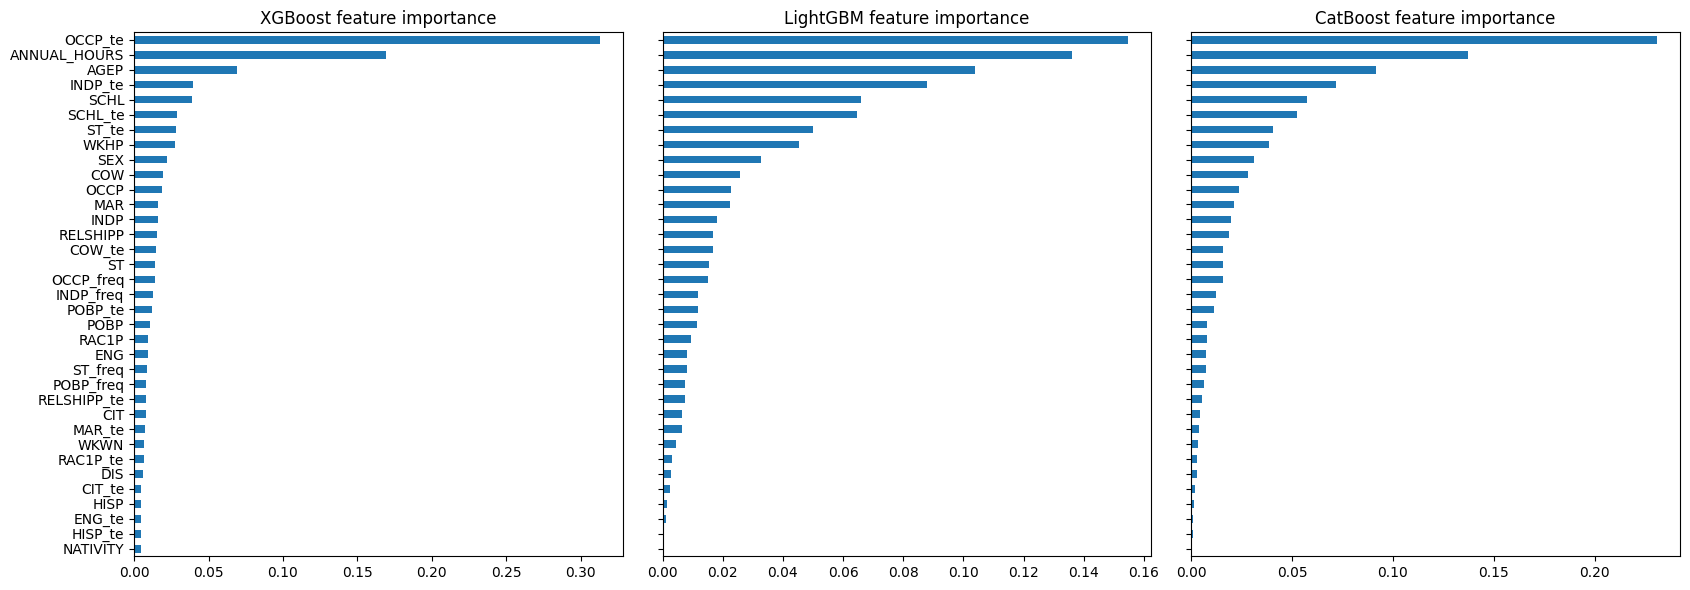

In [24]:
# Feature importance per TREE model (normalised to sum=1 so the three are comparable).
# The linear baselines are excluded here: their "importance" lives in hundreds of
# post-one-hot coefficients, not the 12 raw features, so they aren't directly comparable.
TREE_MODELS = {k: MODELS[k] for k in ("XGBoost", "LightGBM", "CatBoost")}
fig, ax = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
for a, (name, (m, _, _)) in zip(ax, TREE_MODELS.items()):
    imp = pd.Series(m.get_feature_importance() if name == "CatBoost"
                    else m.feature_importances_, index=list(X_train.columns))
    (imp / imp.sum()).sort_values().plot(kind="barh", ax=a)
    a.set_title(f"{name} feature importance")
plt.tight_layout(); plt.show()

## Stage 12 — Model Saving & Inference

Persist **all ten** fitted models (three linear pipelines, three boosters, RandomForest/ExtraTrees/HistGB, and the stacking blender) plus the shared preprocessing metadata (feature list, categorical columns, target transform, dollar scale) so inference reproduces the exact pipeline (saved as `acs2024_income_models_baseline.pkl`). The best model by Test R² is used for the sanity-check prediction.

> **Note:** the `Stacking(GBMs)` entry is a `StackedGBM` instance; reloading the bundle in a *fresh* process needs that class definition in scope (re-run Stage 8, or move the class into an importable module before deploying).

In [25]:
# import joblib

# best_name = results_df.loc[results_df["Test R2"].idxmax(), "Algorithm"]
# bundle = {
#     "models": {n: t[0] for n, t in MODELS.items()},
#     "best_model": best_name,
#     "features": list(X_train.columns),
#     "cat_features": CAT_FEATURES,
#     "target": TARGET_COLUMN,
#     "target_transform": "log1p / expm1",
#     "wagp_to_dollars": WAGP_TO_DOLLARS,
#     "generated_features": GENERATED_COLS,
#     "survey_year": "2024",
#     "results": results_df,
# }
# joblib.dump(bundle, "acs2024_income_models_exp5.pkl")
# print("Saved acs2024_income_models_exp5.pkl | best model:", best_name)

# # Reload and predict on a sample with the best model (invert log1p, x1e6 -> dollars).
# loaded = joblib.load("acs2024_income_models_baseline.pkl")
# m, X_tr, X_te = MODELS[loaded["best_model"]]
# scale = loaded["wagp_to_dollars"]
# sample_pred = np.expm1(m.predict(X_te[:5])) * scale
# print("\nGround-truth WAGP:", [f"${v:,.0f}" for v in y_test_raw.values[:5] * scale])
# print("Predicted   WAGP:", [f"${v:,.0f}" for v in sample_pred])

---
## Experiment Log — exp5 (encoded learners + diversified 6-base stack)

Ten regressors on the **raw 18 features + `ANNUAL_HOURS` + leak-safe OOF target/frequency
encodings** of the high/medium-card codes. Boosters use native categoricals; RF/ExtraTrees/
HistGB and the linear models read the high-card signal through the numeric `*_te`/`*_freq`
columns; the stack blends **six** tree learners with a Ridge meta. MAE/RMSE in dollars
(×1e6 scale), R² scale-free. Best Test R² in **bold**.

| Algorithm | Modifications | Train MAE | Train RMSE | Train R² | Test MAE | Test RMSE | Test R² |
|---|---|---|---|---|---|---|---|
| Ridge | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 33,413.07 | 65,070.78 | 0.40 | 33,066.79 | 63,661.31 | 0.409 |
| Linear | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 33,414.33 | 65,066.94 | 0.40 | 33,060.83 | 63,666.33 | 0.409 |
| Lasso | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 33,383.06 | 65,192.11 | 0.40 | 33,020.95 | 63,729.10 | 0.407 |
| XGBoost | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 22,083.98 | 45,078.04 | 0.71 | 28,293.15 | 58,927.22 | 0.493 |
| LightGBM | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 25,961.07 | 52,843.09 | 0.60 | 28,118.30 | 58,228.09 | 0.505 |
| CatBoost | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 27,422.75 | 56,597.17 | 0.54 | 28,212.08 | 58,419.47 | 0.502 |
| RandomForest | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 18,838.62 | 43,191.34 | 0.73 | 28,629.42 | 59,172.43 | 0.489 |
| ExtraTrees | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 17,921.12 | 41,192.29 | 0.76 | 28,302.38 | 58,983.01 | 0.492 |
| HistGradientBoosting | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 27,416.06 | 56,003.92 | 0.55 | 28,341.19 | 58,478.99 | 0.501 |
| **Stacking(GBMs)** | exp5: raw + ANNUAL_HOURS + OOF target/freq enc (6-base stack) | 24,512.87 | 51,281.12 | 0.63 | **27,728.43** | **58,046.79** | **0.5084** |

> Live from **Stage 11** (`results_df`); saved run: CatBoost best_iter 1789, XGBoost 216,
> LightGBM 261; 6-base Ridge meta weights XGB/LGBM/Cat/RF/ET/HGB ≈
> +0.14/+0.26/+0.31/+0.04/+0.10/+0.14. **Best: Stacking(GBMs) — Test R² 0.5084, MAE \$27,728**
> (also the lowest MAE). The blend uses all six bases, leaning on CatBoost + LightGBM.

### exp5 vs. baseline (raw-18) vs. exp2 (current family best) — Test R²

| Model | base | exp2 | **exp5** | exp5 − base |
|---|---|---|---|---|
| Ridge | 0.4264 | 0.4284 | 0.4087 | **−0.018** |
| Linear | 0.4263 | 0.4275 | 0.4086 | −0.018 |
| Lasso | 0.3788 | 0.4131 | 0.4075 | +0.029 |
| XGBoost | 0.4952 | 0.4961 | 0.4934 | −0.002 |
| LightGBM | 0.5048 | 0.5054 | 0.5053 | +0.001 |
| CatBoost | 0.4966 | 0.5034 | 0.5021 | **+0.005** |
| RandomForest | 0.4643 | 0.4877 | 0.4892 | **+0.025** |
| ExtraTrees | 0.4520 | 0.4908 | 0.4924 | **+0.040** |
| HistGradientBoosting | 0.4887 | 0.4996 | 0.5011 | **+0.012** |
| **Stacking(GBMs)** | **0.5079** | **0.5085** | **0.5084** | **+0.0005** |

**Headline:** exp5's stack lands at **Test R² 0.5084** — a **statistical tie with exp2 (0.5085)**
and a hair above the raw-18 baseline (0.5079). exp5 is therefore **(tied) best in the family**,
and it makes the *cleanest single-model case for the encodings*: the four learners that cannot
natively read high-card codes gain the most — **ExtraTrees +0.040, RandomForest +0.025,
HistGB +0.012, CatBoost +0.005** over baseline — exactly because the `*_te`/`*_freq` columns
hand them the granular `OCCP/INDP/POBP/ST` wage signal they otherwise read as meaningless
ordinals. The 6-base Ridge blend then genuinely uses those strengthened bagging learners
(non-zero weights for RF/ET/HGB), not just the boosters.

**Why it ties rather than beats:**
- The boosters already extracted the high-card signal natively, so encoding is redundant *for
  them*; the gains accrue to the weak learners, which the stack only partially leverages.
- The **linear family regressed −0.018** — the one routing trade-off in exp5. Swapping the
  baseline's full high-card one-hot (hundreds of `OCCP/INDP` dummies = lots of raw signal) for a
  single target-encoded column per code cost the linear models more signal than the encoding
  returned. This is harmless to the headline (linear models are **not** in the stack), but it is
  the honest cost of the routing change. exp2 kept the one-hot *and* added freq columns, so its
  linear scores held at ~0.428.
- The field still clusters at **Test R² ≈ 0.508–0.509**, re-confirming the **feature-bound
  ceiling** for the fourth independent time (exp2 add encodings, exp3 remove granularity, exp4
  add interactions/stack, exp5 encodings + diversified blend). No re-encoding / re-blending of
  the existing 18 columns breaks past ~0.51.

**Takeaways:**
- **Encodings are the right lever for the weak learners** — exp5 posts the family-best RF/ET/HGB
  single-model scores. But because the stack already had native-categorical boosters at the
  ceiling, strengthening the laggards only ties, not beats.
- **Don't drop the high-card one-hot for linear models** — give them the encodings *in addition*
  (exp2's choice), not *instead* (exp5's), if their standalone scores matter.
- Real gains still require **richer raw predictors** (PUMA geography, finer occupation,
  employer/tenure, `PWGTP` weights, top-coded-tail modelling), not more transforms of these 18
  columns. exp5 is the strongest confirmation yet that the ~0.51 wall is in the data.

*Notebook scaffold generated from `ML_Model_Building_Template.md`, wired to `acs2024_income.csv`.*
